In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd

Plotting of 1D Surfaces

['/media/storage_6/lme/formic_acid/fad/print_surface/plots1/V1D_5_1.dat']


/tmp/ipykernel_453504/3264631532.py:18: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(path, delim_whitespace=True, header=None)


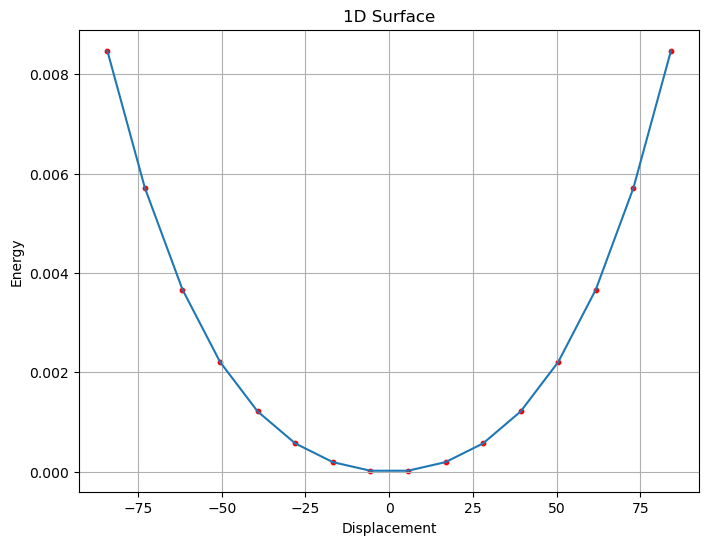

In [3]:
path_to_plots = "/media/storage_6/lme/formic_acid/fad/print_surface/plots1"

# Loop through all files

paths_1D = []

mode_numbers = [5]
for filename in os.listdir(path_to_plots):
    if "1D" in filename and filename.endswith(".dat"):
        for mode_number in mode_numbers:
            if f"_{mode_number}_" in filename:
                full_path = os.path.join(path_to_plots, filename)
                paths_1D.append(full_path)

# open up the files and plot the modes
print(paths_1D)
for path in paths_1D:
    data = pd.read_csv(path, delim_whitespace=True, header=None)
    x = data[0].values
    y = data[1].values
    plt.figure(figsize=(8, 6))
    plt.plot(x, y)
    # Plot points
    plt.scatter(x, y, color='red', s=10)
    plt.title(f"1D Surface")
    plt.xlabel("Displacement")
    plt.ylabel("Energy")
    plt.grid()
    plt.show()

Plotting of 2D Surfaces

Following Surface will be plotted:
['/media/storage_6/lme/formic_acid/fad/print_surface/plots1/V2D_14_12.dat']


/tmp/ipykernel_453504/1538714430.py:17: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(path, delim_whitespace=True, header=None)


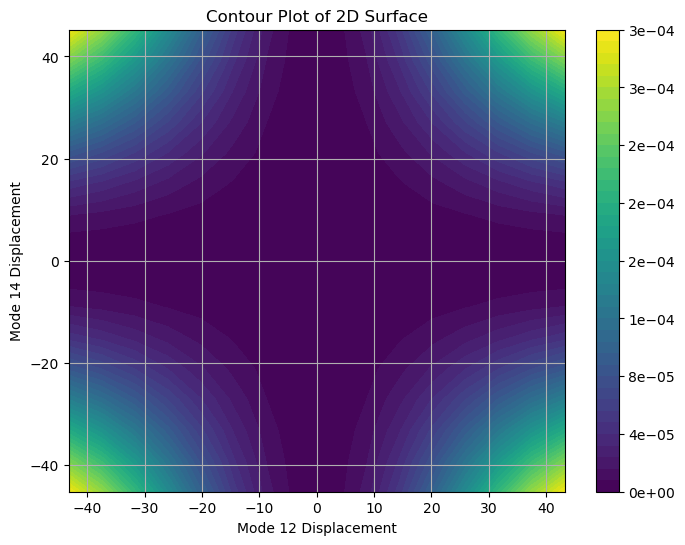

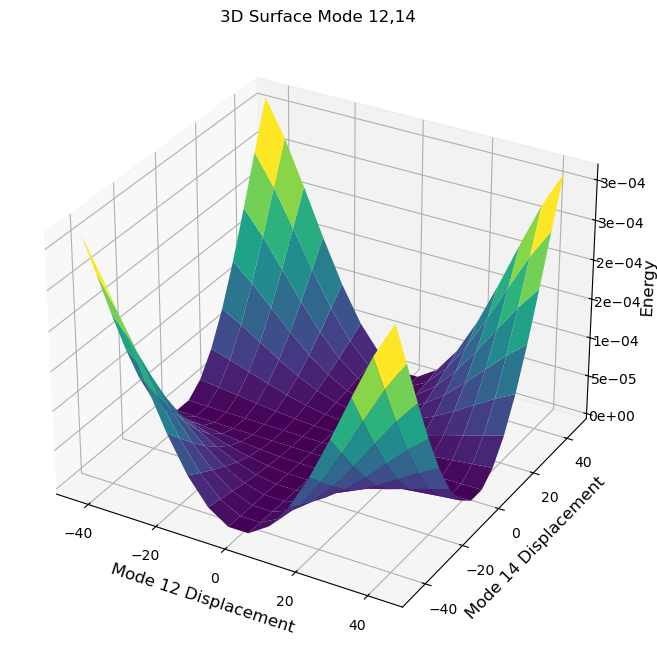

In [28]:
path_to_plots='/media/storage_6/lme/formic_acid/fad/print_surface/plots1'

paths_2D = []

mode_1 = 12
mode_2 = 14

for filename in os.listdir(path_to_plots):
    if "2D" in filename and filename.endswith(".dat") and not "COMPLETE" in filename:
        if (f"_{mode_1}_" in filename and f"_{mode_2}" in filename) or (f"_{mode_2}_" in filename and f"_{mode_1}" in filename):
            full_path = os.path.join(path_to_plots, filename)
            paths_2D.append(full_path)
print("Following Surface will be plotted:")
print(paths_2D)

for path in paths_2D:
    data = pd.read_csv(path, delim_whitespace=True, header=None)
    x = data[0].values
    y = data[1].values
    z = data[2].values
    # Reshape the data for 2D plotting
    xi = np.unique(x)
    yi = np.unique(y)
    zi = z.reshape(len(yi), len(xi))

    # Make Contour Plot
    plt.figure(figsize=(8, 6))
    cp = plt.contourf(xi, yi, zi, levels=50, cmap='viridis')
    # Label Colorbar in scientific notation
    cbar = plt.colorbar(cp)
    cbar.ax.yaxis.set_major_formatter('{x:.0e}')
    plt.title(f"Contour Plot of 2D Surface")
    plt.xlabel(f"Mode {mode_1} Displacement")
    plt.ylabel(f"Mode {mode_2} Displacement")
    plt.grid()
    plt.show()
    # Make 3D Plot
    from mpl_toolkits.mplot3d import Axes3D
    X, Y = np.meshgrid(xi, yi)
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(X, Y, zi, cmap='viridis')
    ax.set_title(f"3D Surface Mode {mode_1},{mode_2}")
    ax.set_xlabel(f"Mode {mode_1} Displacement")
    ax.set_ylabel(f"Mode {mode_2} Displacement")
    ax.set_zlabel("Energy")
    # Make Labels more readable
    ax.xaxis.label.set_size(12)
    ax.yaxis.label.set_size(12)
    ax.zaxis.label.set_size(12)
    # Format z axis ticks to exponential notation
    ax.zaxis.set_major_formatter('{x:.0e}')
    plt.show()

['/media/storage_6/lme/formic_acid/fad/mp2_localized_test/mp2_without_localization/test/plots1/V1D_5_1.dat']


/tmp/ipykernel_2926229/1810974314.py:18: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(path, delim_whitespace=True, header=None)


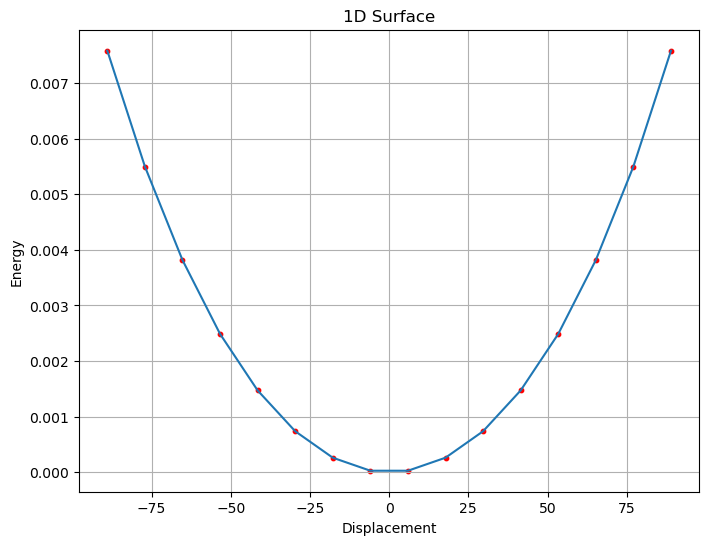

           2
9.521e-07 x - 1.778e-21 x - 0.0001115


In [4]:
path_to_plots = "/media/storage_6/lme/formic_acid/fad/mp2_localized_test/mp2_without_localization/test/plots1"

# Loop through all files

paths_1D = []

mode_numbers = [5]
for filename in os.listdir(path_to_plots):
    if "1D" in filename and filename.endswith(".dat"):
        for mode_number in mode_numbers:
            if f"_{mode_number}_" in filename:
                full_path = os.path.join(path_to_plots, filename)
                paths_1D.append(full_path)

# open up the files and plot the modes
print(paths_1D)
for path in paths_1D:
    data = pd.read_csv(path, delim_whitespace=True, header=None)
    x = data[0].values
    y = data[1].values
    plt.figure(figsize=(8, 6))
    plt.plot(x, y)
    # Plot points
    plt.scatter(x, y, color='red', s=10)
    plt.title(f"1D Surface")
    plt.xlabel("Displacement")
    plt.ylabel("Energy")
    plt.grid()
    plt.show()
    # Fit polynomial to data
    coeffs = np.polyfit(x, y, deg=2)
    poly = np.poly1d(coeffs)
    print(poly)


    





[-84.1697977584, -56.1131985056, -42.0848988792, -28.0565992528, -14.0282996264, 0.0, 14.0282996264, 28.0565992528, 42.0848988792, 56.1131985056, 84.1697977584]


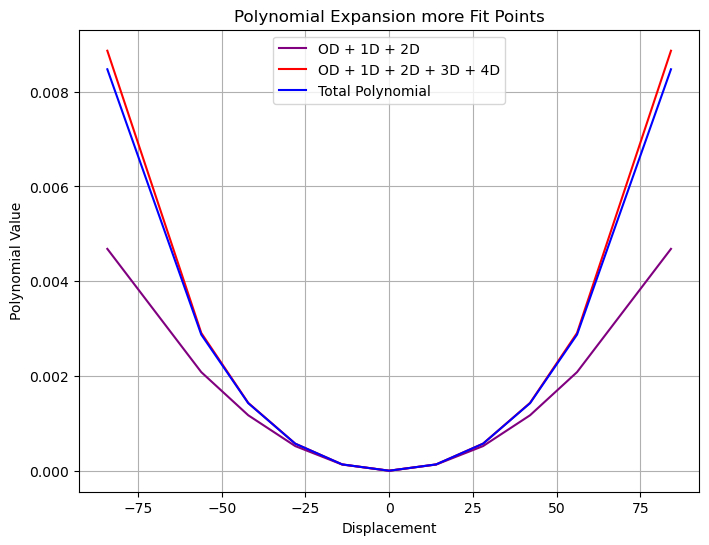

In [36]:
# Plot Influence of Terms in Polynomial Expansion

# Mode 5 REF = 259.20 cm^-1, Fit 252.34 cm^-1

# Poly b_i(x) = x^(i-1)

coefficients_mode5= """
  1    -2.66094712E-07
  2     3.91534987E-18
  3     6.60994927E-07
  4     8.47948939E-21
  5     8.33341301E-11
  6    -4.86164234E-25
  7    -1.10096463E-15
  8    -6.37221736E-29
"""
coeffs = [float(line.split()[1]) for line in coefficients_mode5.strip().split("\n")]

displacements = """
    -84.1697977584  
    -56.1131985056  
    -42.0848988792  
    -28.0565992528  
    -14.0282996264  
      0.0000000000  
     14.0282996264  
     28.0565992528  
     42.0848988792  
     56.1131985056  
     84.1697977584  
"""
displacements = [float(line) for line in displacements.strip().split("\n")]
print(displacements)

y_1D = coeffs[1] * np.array(displacements)
y_2D = coeffs[2] * np.array(displacements)**2
y_3D = coeffs[3] * np.array(displacements)**3
y_4D = coeffs[4] * np.array(displacements)**4
y_5D = coeffs[5] * np.array(displacements)**5
y_6D = coeffs[6] * np.array(displacements)**6
y_7D = coeffs[7] * np.array(displacements)**7

y_0D_1D_2D = coeffs[0] + y_1D + y_2D
y_0D_1D_2D_3D_4D = coeffs[0] + y_1D + y_2D + y_3D + y_4D
y_total = coeffs[0] + y_1D + y_2D + y_3D + y_4D + y_5D + y_6D + y_7D

plt.figure(figsize=(8, 6))
plt.plot(displacements,y_0D_1D_2D, label='OD + 1D + 2D', color='purple')
plt.plot(displacements, y_0D_1D_2D_3D_4D, label='OD + 1D + 2D + 3D + 4D', color='red')
plt.plot(displacements, y_total, label="Total Polynomial", color='blue')
plt.title('Polynomial Expansion more Fit Points')
plt.legend()
plt.xlabel('Displacement')
plt.ylabel('Polynomial Value')
plt.grid()
plt.show()



[-31.312292748, -20.874861832, -15.656146374, -10.437430916, -5.218715458, 0.0, 5.218715458, 10.437430916, 15.656146374, 20.874861832, 31.312292748]


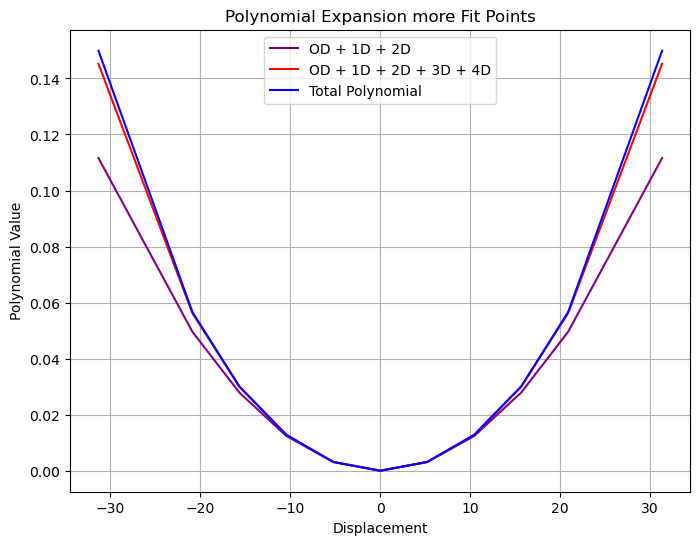

In [37]:
# Comparison to Mode 24

coefficients_mode24= """
  1    -2.40037075E-06
  2    -4.93789208E-17
  3     1.13815838E-04
  4    -4.73589724E-19
  5     3.49931716E-08
  6    -1.38238968E-21
  7     4.95634212E-12
  8    -4.59181495E-25
"""
coeffs = [float(line.split()[1]) for line in coefficients_mode24.strip().split("\n")]

displacements = """
    -31.3122927480   
    -20.8748618320   
    -15.6561463740   
    -10.4374309160   
     -5.2187154580   
      0.0000000000   
      5.2187154580   
     10.4374309160   
     15.6561463740   
     20.8748618320   
     31.3122927480   
"""
displacements = [float(line) for line in displacements.strip().split("\n")]
print(displacements)

y_1D = coeffs[1] * np.array(displacements)
y_2D = coeffs[2] * np.array(displacements)**2
y_3D = coeffs[3] * np.array(displacements)**3
y_4D = coeffs[4] * np.array(displacements)**4
y_5D = coeffs[5] * np.array(displacements)**5
y_6D = coeffs[6] * np.array(displacements)**6
y_7D = coeffs[7] * np.array(displacements)**7

y_0D_1D_2D = coeffs[0] + y_1D + y_2D
y_0D_1D_2D_3D_4D = coeffs[0] + y_1D + y_2D + y_3D + y_4D
y_total = coeffs[0] + y_1D + y_2D + y_3D + y_4D + y_5D + y_6D + y_7D

plt.figure(figsize=(8, 6))
plt.plot(displacements,y_0D_1D_2D, label='OD + 1D + 2D', color='purple')
plt.plot(displacements, y_0D_1D_2D_3D_4D, label='OD + 1D + 2D + 3D + 4D', color='red')
plt.plot(displacements, y_total, label="Total Polynomial", color='blue')
plt.title('Polynomial Expansion more Fit Points')
plt.legend()
plt.xlabel('Displacement')
plt.ylabel('Polynomial Value')
plt.grid()
plt.show()

[-88.9611452737, -59.3074301825, -44.4805726369, -29.6537150912, -14.8268575456, 0.0, 14.8268575456, 29.6537150912, 44.4805726369, 59.3074301825, 88.9611452737]


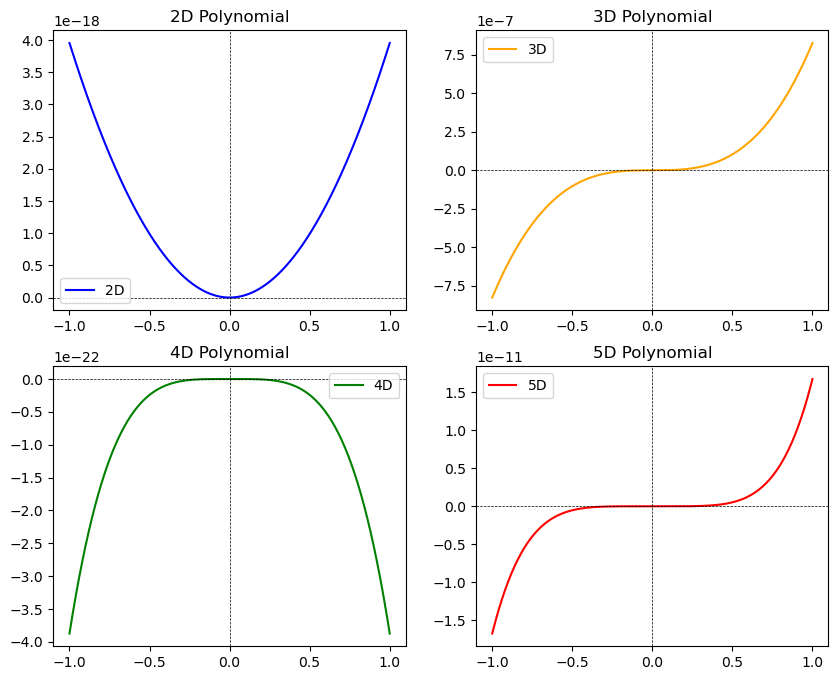

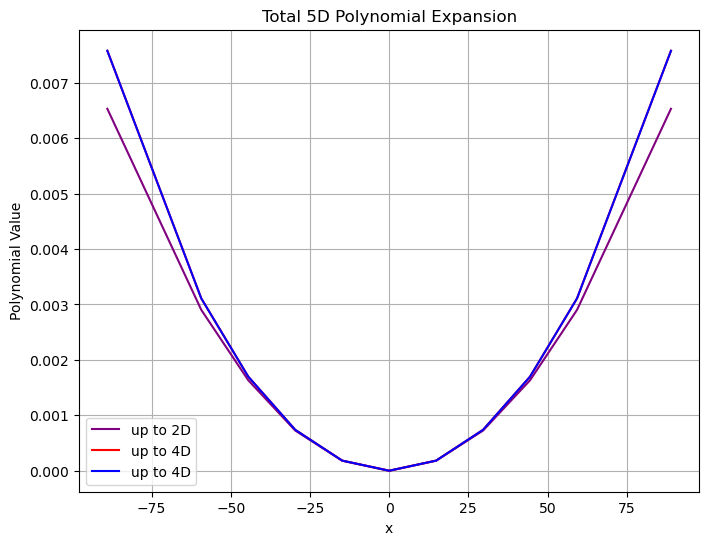

In [6]:

 # Polynomial expansion for mode 20
data20="""
  1    -1.27054284E-08
  2     7.72671623E-17
  3     3.45131036E-05
  4     1.35062996E-19
  5     8.75979559E-10
  6    -3.91135329E-22
  7     1.03315282E-14
  8    -1.01237155E-25
  """

# Mode 19
data19 = """
  1    -2.27103223E-09
  2     4.87360496E-10
  3     3.19620111E-05
  4     1.64481609E-07
  5     7.76805815E-10
  6     3.49434147E-12
  7     9.22003076E-15
  8     2.34767273E-17
"""

# Mode 5
data5 = """ 
  1    -2.36259938E-08
  2     3.95340991E-18
  3     8.25364439E-07
  4    -3.87446210E-22
  5     1.67270935E-11
  6    -1.49663241E-24
  7    -3.10072104E-18
  8     5.99394017E-29
"""
data24 = """
  1    -2.63055673E-06
  2    -3.70153906E-18
  3     1.14337673E-04
  4     2.46836968E-18
  5     3.39504437E-08
  6    -4.82914878E-21
  7     4.62785630E-12
  8     1.22879351E-24
"""

coeffs = []
for line in data5.splitlines()[1:]:
    parts = line.split()
    if len(parts) == 2:
        coeffs.append(float(parts[1]))

# Plot coefficients with increasing order




x = np.linspace(-1, 1, 400)

y_2D = coeffs[1] * x**2 
y_3D = coeffs[2] * x**3
y_4D = coeffs[3] * x**4
y_5D = coeffs[4] * x**5
y_6D = coeffs[5] * x**6
y_7D = coeffs[6] * x**7
y_8D = coeffs[7] * x**8

# subplots for individual plots
fig, axs = plt.subplots(2, 2, figsize=(10, 8)) 
axs[0, 0].plot(x, y_2D, label='2D', color='blue')
axs[0, 0].set_title('2D Polynomial')
axs[0, 0].axhline(0, color='black', lw=0.5, ls='--')
axs[0, 0].axvline(0, color='black', lw=0.5, ls='--')
axs[0, 0].legend() 

axs[0, 1].plot(x, y_3D, label='3D', color='orange')
axs[0, 1].set_title('3D Polynomial')
axs[0, 1].axhline(0, color='black', lw=0.5, ls='--')
axs[0, 1].axvline(0, color='black', lw=0.5, ls='--')
axs[0, 1].legend()  

axs[1, 0].plot(x, y_4D, label='4D', color='green')
axs[1, 0].set_title('4D Polynomial')
axs[1, 0].axhline(0, color='black', lw=0.5, ls='--')
axs[1, 0].axvline(0, color='black', lw=0.5, ls='--')
axs[1, 0].legend()

axs[1, 1].plot(x, y_5D, label='5D', color='red')
axs[1, 1].set_title('5D Polynomial')
axs[1, 1].axhline(0, color='black', lw=0.5, ls='--')
axs[1, 1].axvline(0, color='black', lw=0.5, ls='--')
axs[1, 1].legend()

# Plot the total 5D polynomial expansion

y_total = coeffs[0] + y_2D + y_3D + y_4D + y_5D + y_6D + y_7D + y_8D


x_data=[-88.9611452737,-59.3074301825,-44.4805726369,-29.6537150912  , -14.8268575456    
   ,   0.0000000000    
   ,  14.8268575456    
   ,  29.6537150912    
   ,  44.4805726369    
   ,  59.3074301825    
   ,  88.9611452737 
]
print(x_data)

y_1D = coeffs[1] * (np.array(x_data))
y_2D = coeffs[2] * (np.array(x_data))**2
y_3D = coeffs[3] * (np.array(x_data))**3
y_4D = coeffs[4] * (np.array(x_data))**4
y_5D = coeffs[5] * (np.array(x_data))**5
y_6D = coeffs[6] * (np.array(x_data))**6
y_7D = coeffs[7] * (np.array(x_data))**7

y_up_2D = coeffs[0]+ y_1D + y_2D
y_up_4D = coeffs[0] + y_1D + y_2D + y_3D + y_4D
y_total = coeffs[0] + y_1D + y_2D + y_3D + y_4D + y_5D + y_6D


plt.figure(figsize=(8, 6))
plt.plot(x_data,y_up_2D, label='up to 2D', color='purple')
plt.plot(x_data,y_up_4D, label='up to 4D',color='red')
plt.plot(x_data,y_total, label='up to 4D',color='blue')
plt.title('Total 5D Polynomial Expansion')
plt.legend()
plt.xlabel('x')
plt.ylabel('Polynomial Value')
plt.grid()
plt.show()



    